# EDA — CIC-DDoS2019 Dataset

**Day 2 — Exploratory Data Analysis**

Goals:
1. Understand the raw data structure and column names
2. Check what label values actually exist in each CSV
3. Confirm BENIGN class availability
4. Analyze class distribution (before sampling)
5. Identify NaN, Inf, and constant columns
6. Understand data scale and feature ranges

> ⚠️ **We only LOOK here — no modifications to raw data.**

In [1]:
import sys
sys.path.insert(0, '..')  # so we can import src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.utils.seed import set_seed
from src.utils.logger import get_logger

set_seed(42)
logger = get_logger('eda')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

TRAIN_DIR = Path('../data/raw/01-12')
TEST_DIR  = Path('../data/raw/03-11')

print('Train files:', [f.name for f in sorted(TRAIN_DIR.glob('*.csv'))])
print('Test files: ', [f.name for f in sorted(TEST_DIR.glob('*.csv'))])

[seed] All random seeds set to 42
Train files: ['DrDoS_DNS.csv', 'DrDoS_LDAP.csv', 'DrDoS_MSSQL.csv', 'DrDoS_NetBIOS.csv', 'DrDoS_NTP.csv', 'DrDoS_SNMP.csv', 'DrDoS_SSDP.csv', 'DrDoS_UDP.csv', 'Syn.csv', 'TFTP.csv', 'UDPLag.csv']
Test files:  ['LDAP.csv', 'MSSQL.csv', 'NetBIOS.csv', 'Portmap.csv', 'Syn.csv', 'UDP.csv', 'UDPLag.csv']


## 1. Peek at One CSV — Columns & Label Values

In [2]:
# Load a small sample first to see column names
sample_df = pd.read_csv(TRAIN_DIR / 'DrDoS_LDAP.csv', nrows=5000, low_memory=False)
sample_df.columns = sample_df.columns.str.strip()

print(f'Shape: {sample_df.shape}')
print(f'\nColumn names ({len(sample_df.columns)} total):')
for i, col in enumerate(sample_df.columns):
    print(f'  {i+1:3d}. {col}')

Shape: (5000, 88)

Column names (88 total):
    1. Unnamed: 0
    2. Flow ID
    3. Source IP
    4. Source Port
    5. Destination IP
    6. Destination Port
    7. Protocol
    8. Timestamp
    9. Flow Duration
   10. Total Fwd Packets
   11. Total Backward Packets
   12. Total Length of Fwd Packets
   13. Total Length of Bwd Packets
   14. Fwd Packet Length Max
   15. Fwd Packet Length Min
   16. Fwd Packet Length Mean
   17. Fwd Packet Length Std
   18. Bwd Packet Length Max
   19. Bwd Packet Length Min
   20. Bwd Packet Length Mean
   21. Bwd Packet Length Std
   22. Flow Bytes/s
   23. Flow Packets/s
   24. Flow IAT Mean
   25. Flow IAT Std
   26. Flow IAT Max
   27. Flow IAT Min
   28. Fwd IAT Total
   29. Fwd IAT Mean
   30. Fwd IAT Std
   31. Fwd IAT Max
   32. Fwd IAT Min
   33. Bwd IAT Total
   34. Bwd IAT Mean
   35. Bwd IAT Std
   36. Bwd IAT Max
   37. Bwd IAT Min
   38. Fwd PSH Flags
   39. Bwd PSH Flags
   40. Fwd URG Flags
   41. Bwd URG Flags
   42. Fwd Header Length


In [3]:
# What unique labels exist in this file?
print('Unique labels in DrDoS_LDAP.csv:')
print(sample_df['Label'].value_counts())

Unique labels in DrDoS_LDAP.csv:
Label
DrDoS_LDAP    4999
BENIGN           1
Name: count, dtype: int64


## 2. Check Label Values in ALL Train CSVs

This tells us:
- Exact class name strings (so we can set config correctly)
- Whether BENIGN rows exist inside any of the attack CSVs
- Total row counts per file

In [4]:
print('=== TRAIN (01-12) — Label distribution per file ===')
print()

train_summary = {}
for csv_path in sorted(TRAIN_DIR.glob('*.csv')):
    # Read only the label column for speed
    try:
        df_labels = pd.read_csv(csv_path, usecols=lambda c: c.strip() in ['Label', ' Label'],
                                low_memory=False)
        df_labels.columns = df_labels.columns.str.strip()
        counts = df_labels['Label'].str.strip().value_counts()
        train_summary[csv_path.name] = counts
        print(f'[{csv_path.name}]')
        print(counts.to_string())
        print(f'  Total rows: {len(df_labels):,}')
        print()
    except Exception as e:
        print(f'  ERROR loading {csv_path.name}: {e}')

=== TRAIN (01-12) — Label distribution per file ===

[DrDoS_DNS.csv]
Label
DrDoS_DNS    5071011
BENIGN          3402
  Total rows: 5,074,413

[DrDoS_LDAP.csv]
Label
DrDoS_LDAP    2179930
BENIGN           1612
  Total rows: 2,181,542

[DrDoS_MSSQL.csv]
Label
DrDoS_MSSQL    4522492
BENIGN            2006
  Total rows: 4,524,498

[DrDoS_NetBIOS.csv]
Label
DrDoS_NetBIOS    4093279
BENIGN              1707
  Total rows: 4,094,986

[DrDoS_NTP.csv]
Label
DrDoS_NTP    1202642
BENIGN         14365
  Total rows: 1,217,007

[DrDoS_SNMP.csv]
Label
DrDoS_SNMP    5159870
BENIGN           1507
  Total rows: 5,161,377

[DrDoS_SSDP.csv]
Label
DrDoS_SSDP    2610611
BENIGN            763
  Total rows: 2,611,374

[DrDoS_UDP.csv]
Label
DrDoS_UDP    3134645
BENIGN          2157
  Total rows: 3,136,802

[Syn.csv]
Label
Syn       1582289
BENIGN        392
  Total rows: 1,582,681

  ERROR loading TFTP.csv: Error tokenizing data. C error: out of memory
[UDPLag.csv]
Label
UDP-lag    366461
BENIGN       3705
WebD

In [5]:
print('=== TEST (03-11) — Label distribution per file ===')
print()

test_summary = {}
for csv_path in sorted(TEST_DIR.glob('*.csv')):
    try:
        df_labels = pd.read_csv(csv_path, usecols=lambda c: c.strip() in ['Label', ' Label'],
                                low_memory=False)
        df_labels.columns = df_labels.columns.str.strip()
        counts = df_labels['Label'].str.strip().value_counts()
        test_summary[csv_path.name] = counts
        print(f'[{csv_path.name}]')
        print(counts.to_string())
        print(f'  Total rows: {len(df_labels):,}')
        print()
    except Exception as e:
        print(f'  ERROR loading {csv_path.name}: {e}')

=== TEST (03-11) — Label distribution per file ===

[LDAP.csv]
Label
LDAP       1905191
NetBIOS     202919
BENIGN        5124
  Total rows: 2,113,234

[MSSQL.csv]
Label
MSSQL     5763061
LDAP         9931
BENIGN       2794
  Total rows: 5,775,786

[NetBIOS.csv]
Label
NetBIOS    3454578
BENIGN        1321
  Total rows: 3,455,899

[Portmap.csv]
Label
Portmap    186960
BENIGN       4734
  Total rows: 191,694

[Syn.csv]
Label
Syn       4284751
BENIGN      35790
  Total rows: 4,320,541

[UDP.csv]
Label
UDP       3754680
MSSQL       24392
BENIGN       3134
  Total rows: 3,782,206

[UDPLag.csv]
Label
Syn       606749
UDP       112475
BENIGN      4068
UDPLag      1873
  Total rows: 725,165



## 3. Data Quality Check — NaN, Inf, Constant Columns

Using a sample of one CSV (loading all files would take too much RAM).

In [6]:
# Load a larger sample for quality analysis
df = pd.read_csv(TRAIN_DIR / 'DrDoS_LDAP.csv', nrows=50000, low_memory=False)
df.columns = df.columns.str.strip()
df_numeric = df.select_dtypes(include=[np.number])

print(f'Shape: {df.shape}')
print(f'Numeric columns: {len(df_numeric.columns)}')

# NaN analysis
nan_counts = df_numeric.isna().sum()
inf_counts = np.isinf(df_numeric).sum()
total_invalid = nan_counts + inf_counts

quality_df = pd.DataFrame({
    'NaN_count': nan_counts,
    'Inf_count': inf_counts,
    'Total_invalid': total_invalid,
    'Invalid_%': (total_invalid / len(df) * 100).round(2),
    'Unique_values': df_numeric.nunique(),
    'Mean': df_numeric.mean().round(4),
    'Std': df_numeric.std().round(4),
    'Min': df_numeric.min().round(4),
    'Max': df_numeric.max().round(4),
})

# Show problematic columns
print('\n=== Columns with ANY NaN or Inf ===')
print(quality_df[quality_df['Total_invalid'] > 0].sort_values('Invalid_%', ascending=False))

Shape: (50000, 88)
Numeric columns: 82


c:\Users\tanis\OneDrive\Desktop\Projects\DDOS\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)



=== Columns with ANY NaN or Inf ===
                NaN_count  Inf_count  Total_invalid  Invalid_%  Unique_values  \
Flow Bytes/s            0       1227           1227     2.4500            566   
Flow Packets/s          0       1227           1227     2.4500            273   

                Mean  Std    Min  Max  
Flow Bytes/s     inf  NaN 0.0000  inf  
Flow Packets/s   inf  NaN 1.3985  inf  


In [7]:
# Zero-variance columns (constant — useless features)
print('=== Zero-variance columns (single unique value) ===')
zero_var = quality_df[quality_df['Unique_values'] <= 1]
if len(zero_var) > 0:
    print(zero_var[['Unique_values', 'Mean', 'Std']])
else:
    print('None found (good!)')

=== Zero-variance columns (single unique value) ===
                       Unique_values   Mean    Std
Bwd Packet Length Min              1 0.0000 0.0000
Bwd PSH Flags                      1 0.0000 0.0000
Fwd URG Flags                      1 0.0000 0.0000
Bwd URG Flags                      1 0.0000 0.0000
FIN Flag Count                     1 0.0000 0.0000
PSH Flag Count                     1 0.0000 0.0000
ECE Flag Count                     1 0.0000 0.0000
Fwd Avg Bytes/Bulk                 1 0.0000 0.0000
Fwd Avg Packets/Bulk               1 0.0000 0.0000
Fwd Avg Bulk Rate                  1 0.0000 0.0000
Bwd Avg Bytes/Bulk                 1 0.0000 0.0000
Bwd Avg Packets/Bulk               1 0.0000 0.0000
Bwd Avg Bulk Rate                  1 0.0000 0.0000
Active Mean                        1 0.0000 0.0000
Active Std                         1 0.0000 0.0000
Active Max                         1 0.0000 0.0000
Active Min                         1 0.0000 0.0000
Idle Mean                     

## 4. Feature Correlation — Quick Overview

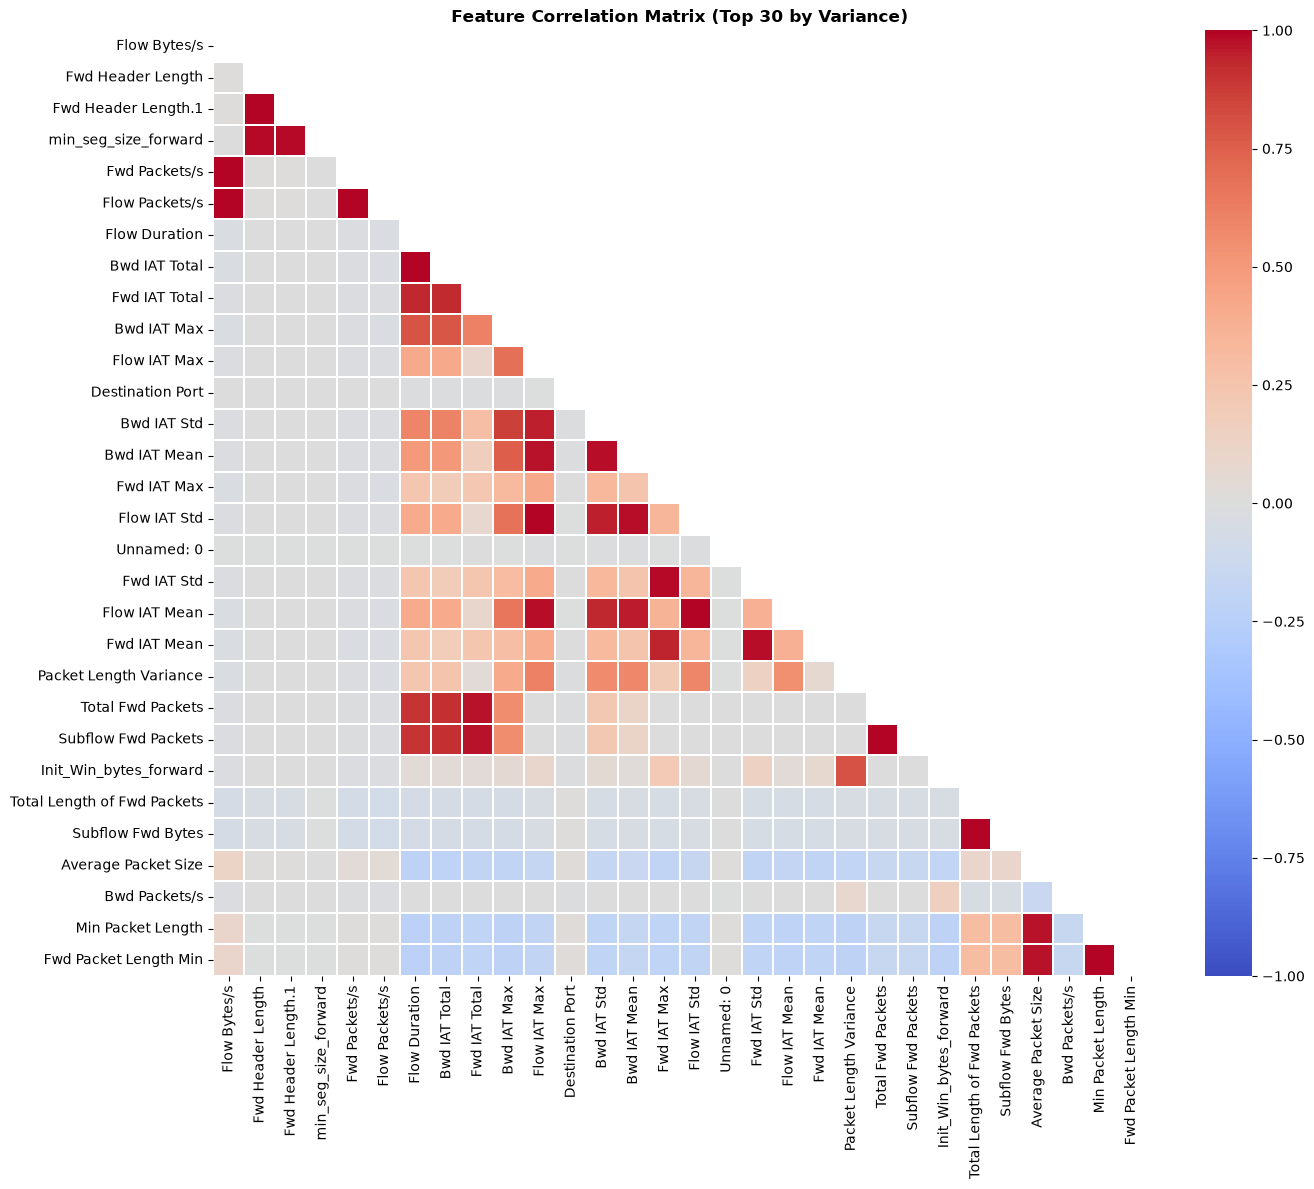

Saved: experiments/results/feature_correlation.png


In [8]:
# Correlation matrix of a subset of features
# Drop known leaky columns first
leaky = ['Flow ID', 'Source IP', 'Destination IP', 'Source Port', 'Timestamp', 'SimillarHTTP', 'Label']
clean_df = df.drop(columns=[c for c in leaky if c in df.columns], errors='ignore')
clean_numeric = clean_df.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)

# Correlation among top-30 features by variance
top_var_cols = clean_numeric.var().nlargest(30).index
corr = clean_numeric[top_var_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix (Top 30 by Variance)', fontweight='bold')
plt.tight_layout()
plt.savefig('../experiments/results/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: experiments/results/feature_correlation.png')

## 5. Feature Distributions — Box Plots

Quick visual of which features have extreme outliers (justifies RobustScaler choice).

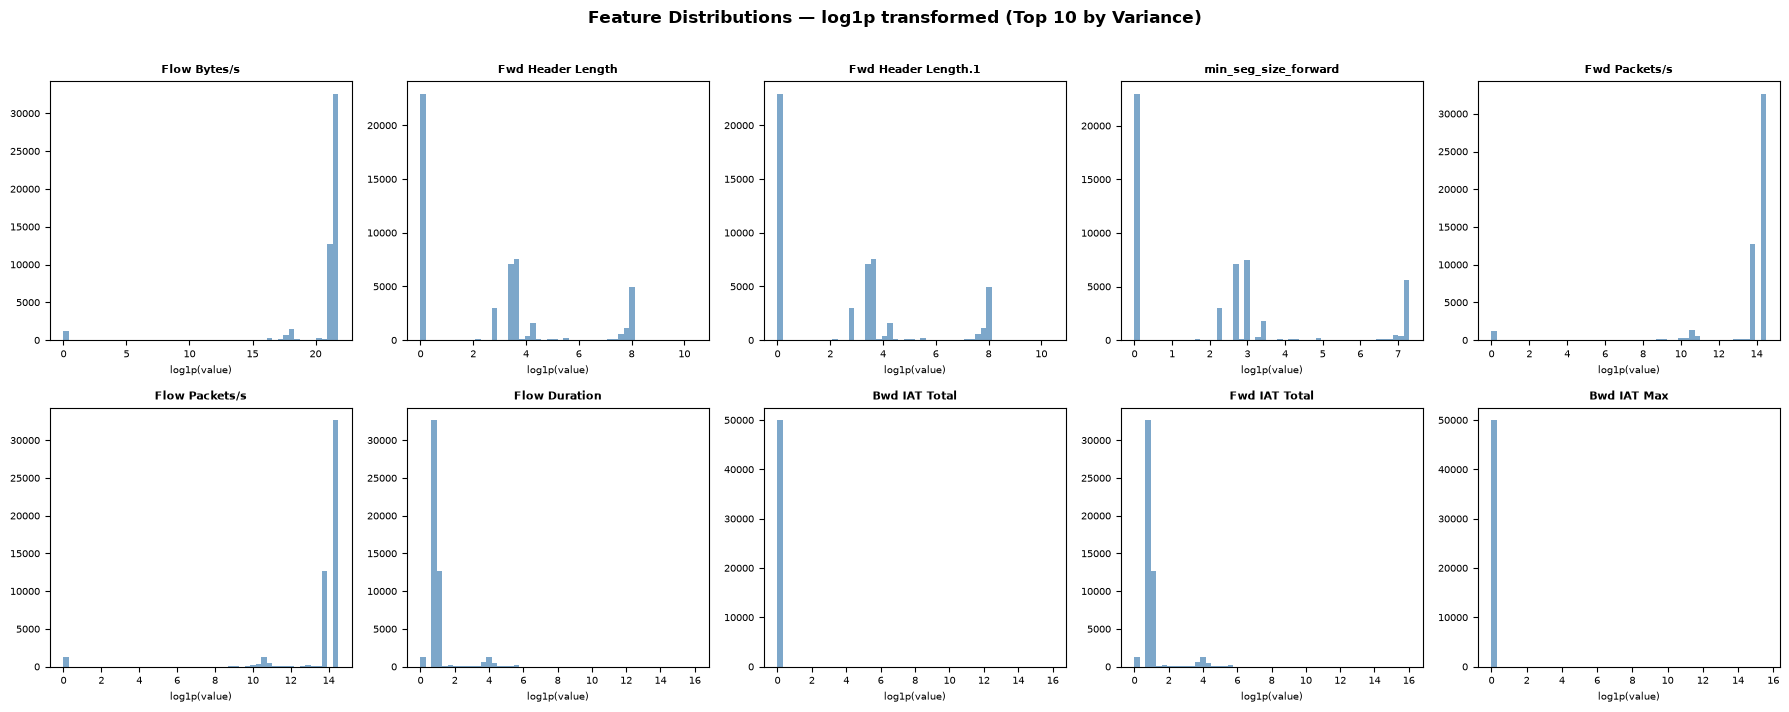

Saved: experiments/results/feature_distributions.png


In [9]:
# Select top 10 features by variance for visualization
top10 = clean_numeric[top_var_cols[:10]].replace([np.inf, -np.inf], np.nan).fillna(0)

# Log-transform for better visualization (many features are right-skewed)
top10_log = np.log1p(top10.clip(lower=0))

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(top10_log.columns):
    axes[i].hist(top10_log[col].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(col[:25], fontsize=8, fontweight='bold')
    axes[i].set_xlabel('log1p(value)', fontsize=7)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Feature Distributions — log1p transformed (Top 10 by Variance)', 
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../experiments/results/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: experiments/results/feature_distributions.png')

## 6. Summary & Next Steps

Fill in these answers after running all cells above:

| Question | Answer |
|----------|--------|
| Total columns in CSVs | 88 (1 index + 5 meta + 1 protocol + 79 numeric features + 1 label + 1 SimillarHTTP) |
| Exact label strings | DrDoS_DNS, DrDoS_LDAP, DrDoS_MSSQL, DrDoS_NetBIOS, DrDoS_NTP, DrDoS_SNMP, DrDoS_SSDP, DrDoS_UDP, Syn, UDP-lag, WebDDoS, BENIGN |
| BENIGN rows in train CSVs? | ~31,616 total spread across all files (392–14,365 per file). Enough to sample 25k. |
| BENIGN rows in test CSVs? | ~56,965 total (Syn.csv alone has 35,790 BENIGN rows) |
| Columns with >50% NaN/Inf | None — only Flow Bytes/s + Flow Packets/s have ~2.45% Inf values (zero-duration flows) |
| Zero-variance columns | 21 columns — all constant = 0 (Bwd Packet Length Min, all Bulk Rate columns, all Active/Idle columns) |

**Day 3 → Feature audit notebook (`02_feature_audit.ipynb`) and `scripts/preprocess.py`**